# MarketScout

!pip install -r requirements.txt

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

checks = {
    ".env file": Path(".env").exists(),
    "GOOGLE_API_KEY": bool(os.getenv("GOOGLE_API_KEY")),
    "TAVILY_API_KEY": bool(os.getenv("TAVILY_API_KEY")),
}

for name, ok in checks.items():
    print(f"{'OK' if ok else 'MISSING':<8} {name}")

if not checks[".env file"]:
    print("\nCreate a .env file by copying .env.example and filling in your API keys.")

OK       .env file
OK       GOOGLE_API_KEY
OK       TAVILY_API_KEY


/Users/chancheahcha/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CS5260-nn2/CS5260_MarketScout/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


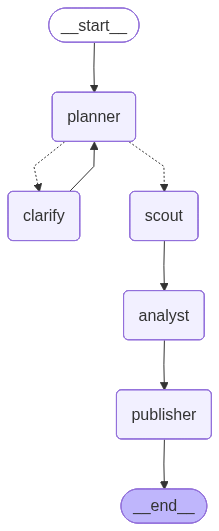

In [2]:
from agent.graph import graph

graph

## Orchestrator

In [3]:
from agent.workers.planner import planner_node
from agent.state import MarketScoutState

test_state: MarketScoutState = {
    "user_query": "I want to open an artisan coffee shop in Austin, Texas",
    "business_idea": "",
    "target_location": "",
    "search_queries": [],
    "raw_results": [],
    "analysis": {},
    "report": "",
    "clarification_attempts": 0,
}
result = planner_node(test_state, {})

print(f"business_idea   : {result['business_idea']}")
print(f"target_location : {result['target_location']}")
print(f"search_queries  :")
for q in result["search_queries"]:
    print(f"  • {q}")

[Planner] Business idea : artisan coffee shop
[Planner] Location      : Austin, Texas
[Planner] Search queries:
          • artisan coffee shops Austin TX
          • best artisan coffee Austin TX Yelp
          • Austin TX coffee shop complaints Reddit
          • what's missing Austin coffee scene
          • top rated coffee shops Austin Texas
          • specialty coffee Austin TX
business_idea   : artisan coffee shop
target_location : Austin, Texas
search_queries  :
  • artisan coffee shops Austin TX
  • best artisan coffee Austin TX Yelp
  • Austin TX coffee shop complaints Reddit
  • what's missing Austin coffee scene
  • top rated coffee shops Austin Texas
  • specialty coffee Austin TX


In [4]:
test_state: MarketScoutState = {
    "user_query": "I want to open a coffee shop",
    "business_idea": "",
    "target_location": "",
    "search_queries": [],
    "raw_results": [],
    "analysis": {},
    "report": "",
    "clarification_attempts": 0,
}
result = planner_node(test_state, {})

[Planner] Business idea : coffee shop
[Planner] Location      : UNKNOWN
[Planner] Search queries:
          • coffee shops near me
          • best coffee shops near me reviews
          • coffee shop complaints Reddit
          • what's missing in local coffee scene


In [5]:
test_state: MarketScoutState = {
    "user_query": "I want to open a shop in Austin, Texas",
    "business_idea": "",
    "target_location": "",
    "search_queries": [],
    "raw_results": [],
    "analysis": {},
    "report": "",
    "clarification_attempts": 0,
}
result = planner_node(test_state, {})

[Planner] Business idea : retail shop
[Planner] Location      : Austin, Texas
[Planner] Search queries:
          • retail shops in Austin TX
          • best retail stores Austin TX Yelp
          • retail shopping complaints Austin TX Reddit
          • what's missing in Austin TX retail
          • unique retail concepts Austin TX
          • popular shopping areas Austin TX


# Scout

In [1]:
from agent.workers.scout import scout_node
from agent.state import MarketScoutState

scout_test_state: MarketScoutState = {
    "user_query": "I want to open an artisan coffee shop in Austin, Texas",
    "business_idea": "artisan coffee shop",
    "target_location": "Austin, Texas",
    "search_queries": [
        "artisan coffee shops Austin TX",
        "best artisan coffee Austin TX Yelp",
        "Austin TX coffee shop complaints Reddit",
    ],
    "raw_results": [],
    "analysis": {},
    "report": "",
    "clarification_attempts": 0,
}

result = scout_node(scout_test_state)

print(f"\nTotal query groups: {len(result['raw_results'])}\n")
for group in result["raw_results"]:
    print(f"Query  : {group['query']}")
    print(f"Answer : {group['answer'][:120] if group['answer'] else 'N/A'}")
    for r in group["results"]:
        print(f"  - {r['name']}")
        print(f"      url    : {r['url']}")
        print(f"      snippet: {r['snippet'][:120]}")
    print()

[Scout] Searching: artisan coffee shops Austin TX
[Scout] Answer: Hank's, Cenote, and Flat Track Coffee Roasters are top artisan coffee shops in Austin, Texas. Caffe Medici and Fleet Coffee Shop also stand out for specialty coffee.
[Scout] Searching: best artisan coffee Austin TX Yelp
[Scout] Answer: In Austin, TX, Merit Coffee, Houndstooth Coffee, and Mozart's Coffee Roasters are highly recommended for artisan coffee. These spots are popular choices on Yelp.
[Scout] Searching: Austin TX coffee shop complaints Reddit
[Scout] Answer: Austin has mixed reviews for its coffee shops; some praise the quality, while others criticize the atmosphere and comfort. Popular spots like Barrett's are highly recommended, but others like Cuppa Austin receive negative feedback. Individual experiences vary widely.
[Scout] Collected 3 results across 3 queries

Total query groups: 3

Query  : artisan coffee shops Austin TX
Answer : Hank's, Cenote, and Flat Track Coffee Roasters are top artisan coffee shops

## Pipeline - To see the outputs from each worker node

In [3]:
QUERY = "I want to open an artisan coffee shop in Austin, Texas"

initial_state: MarketScoutState = {
    "user_query": QUERY,
    "business_idea": "",
    "target_location": "",
    "search_queries": [],
    "raw_results": [],
    "analysis": {},
    "report": "",
    "clarification_attempts": 0,
}

for step in graph.stream(initial_state, stream_mode="updates"):
    node_name, updates = next(iter(step.items()))
    print(f"\n{'=' * 50}")
    print(f"  NODE: {node_name}")
    print(f"{'=' * 50}")
    for key, value in updates.items():
        if isinstance(value, str) and len(value) > 120:
            print(f"  {key}: {value[:120]}")
        elif isinstance(value, list) and len(value) > 3:
            print(f"  {key}: [{len(value)} items] {value[:2]}")
        else:
            print(f"  {key}: {value}")

[Planner] Business idea : artisan coffee shop
[Planner] Location      : Austin, Texas
[Planner] Search queries:
          • artisan coffee shops Austin TX
          • best artisan coffee Austin TX Yelp
          • Austin TX coffee shop complaints Reddit
          • what's missing Austin coffee scene
          • top rated coffee shops Austin Texas
          • specialty coffee Austin TX

  NODE: planner
  business_idea: artisan coffee shop
  target_location: Austin, Texas
  search_queries: [6 items] ['artisan coffee shops Austin TX', 'best artisan coffee Austin TX Yelp']
[Scout] Searching: artisan coffee shops Austin TX
[Scout] Answer: Caffe Medici, Flat Track Coffee Roasters, and Hank’s are top artisan coffee shops in Austin, Texas.
[Scout] Searching: best artisan coffee Austin TX Yelp
[Scout] Answer: Merit Coffee, Houndstooth Coffee, and Mozart's Coffee Roasters are top-rated artisan coffee spots in Austin, TX. These are highly recommended by Yelp users.
[Scout] Searching: Austin TX co

## Full run

In [7]:
final_state = graph.invoke(initial_state)
print(final_state["report"])

[Planner] Business idea : artisan coffee shop
[Planner] Location      : Austin, Texas
[Planner] Search queries:
          • artisan coffee shops Austin TX
          • best artisan coffee Austin TX Yelp
          • Austin TX coffee shop complaints Reddit
          • what's missing Austin TX coffee scene
          • unique coffee shops Austin Texas
          • specialty pour over coffee Austin TX

